# Racial Disparities in North Carolina Traffic Stop Arrests
**SDS 357 — Midterm Analysis**

Analysis of 4M+ traffic stops across six North Carolina cities (2000–2015) from the Stanford Open Policing Project (SOPP), supplemented with FBI Uniform Crime Report data.

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve,
                             confusion_matrix, f1_score, classification_report,
                             precision_score, recall_score)
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)

PALETTE_RACE = {"black": "#4C72B0", "white": "#DD8452",
                "hispanic": "#55A868", "asian/pacific islander": "#C44E52"}
RACE_ORDER = ["black", "white", "hispanic", "asian/pacific islander"]
CITY_ORDER = ["Charlotte", "Raleigh", "Greensboro", "Fayetteville", "Winston-Salem", "Durham"]
SEED = 42

## Data Loading & Preparation

In [62]:
df = pd.read_parquet("nc_traffic_stops_cleaned.parquet")
df = df[df["subject_race"].isin(RACE_ORDER)].copy()
df = df[~df["outcome_missing"]].copy()
df = df[df["hour"].notna() & df["subject_age"].notna()].copy()
df["hour"] = df["hour"].astype(int)
df["subject_age"] = df["subject_age"].astype(float)
df = df.reset_index(drop=True)

# Merge FBI crime rates (violent + property per 1k) by city-year
fbi = pd.read_csv("nc_fbi_crime_data_clean.csv", index_col=0)
fbi["violent_crime_rate"] = fbi["Violent crime"] / fbi["Population"] * 1000
fbi["property_crime_rate"] = fbi["Property crime"] / fbi["Population"] * 1000
df = df.merge(fbi[["City", "Year", "violent_crime_rate", "property_crime_rate"]],
              left_on=["city", "year"], right_on=["City", "Year"], how="left")
df.drop(columns=["City", "Year"], inplace=True)
# Fill years outside FBI coverage with city-level averages
city_avg = fbi.groupby("City")[["violent_crime_rate", "property_crime_rate"]].mean()
for col in ["violent_crime_rate", "property_crime_rate"]:
    df[col] = df.apply(lambda r: city_avg.loc[r["city"], col]
                        if pd.isna(r[col]) else r[col], axis=1)

print(f"Dataset: {len(df):,} stops across {df['city'].nunique()} cities ({int(df['year'].min())}–{int(df['year'].max())})")
print(f"Arrest rate: {df['arrested'].mean()*100:.2f}%")
print(f"FBI crime rates merged: violent_crime_rate and property_crime_rate columns added")
df.head()

Dataset: 3,961,022 stops across 6 cities (2000–2015)
Arrest rate: 2.81%
FBI crime rates merged: violent_crime_rate and property_crime_rate columns added


,date,time,city,subject_race,subject_sex,subject_age,reason_for_stop,outcome,search_conducted,arrested,year,month,day_of_week,hour,outcome_missing,violent_crime_rate,property_crime_rate
0,2000-01-01,17:20:00,Charlotte,black,female,38.0,Safe Movement Violation,warning,False,0,2000,1,Saturday,17,False,7.461077,48.541918
1,2000-01-02,11:40:00,Charlotte,hispanic,male,33.0,Vehicle Regulatory Violation,citation,False,0,2000,1,Sunday,11,False,7.461077,48.541918
2,2000-01-02,02:41:00,Charlotte,white,male,23.0,Vehicle Equipment Violation,citation,False,0,2000,1,Sunday,2,False,7.461077,48.541918
3,2000-01-23,03:35:00,Charlotte,white,female,23.0,Vehicle Regulatory Violation,citation,False,0,2000,1,Sunday,3,False,7.461077,48.541918
4,2000-01-02,16:45:00,Charlotte,white,female,23.0,Safe Movement Violation,warning,False,0,2000,1,Sunday,16,False,7.461077,48.541918


## Exploratory Data Analysis

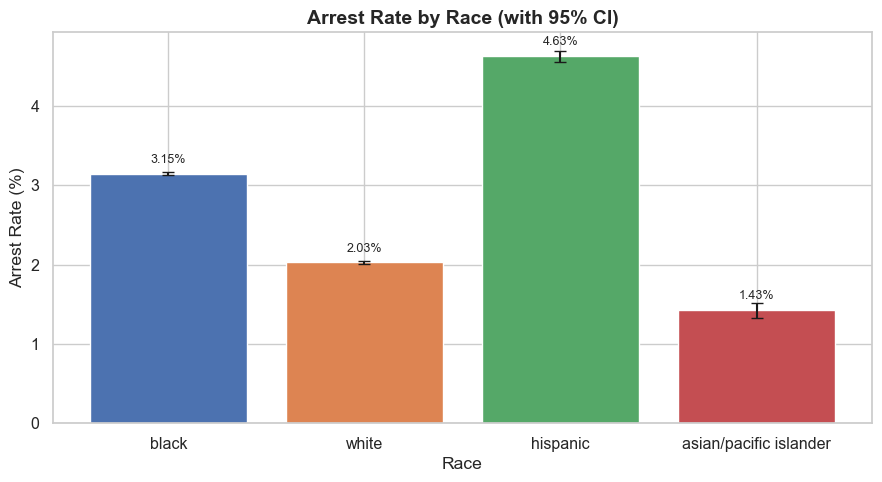

In [63]:
# Figure 1: Arrest Rate by Race (with 95% CI)
def arrest_rate_ci(group, z=1.96):
    n = len(group); p = group.mean()
    se = np.sqrt(p*(1-p)/n) if n > 0 else 0
    return pd.Series({"rate": p*100, "ci": z*se*100, "n": n})

arr_race = df.groupby("subject_race")["arrested"].apply(arrest_rate_ci).unstack()
arr_race = arr_race.reindex([r for r in RACE_ORDER if r in arr_race.index])

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(arr_race.index, arr_race["rate"], yerr=arr_race["ci"], capsize=4,
              color=[PALETTE_RACE[r] for r in arr_race.index], edgecolor="white")
ax.set_title("Arrest Rate by Race (with 95% CI)", fontsize=14, fontweight="bold")
ax.set_xlabel("Race"); ax.set_ylabel("Arrest Rate (%)")
for b, rate in zip(bars, arr_race["rate"]):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.1, f"{rate:.2f}%",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

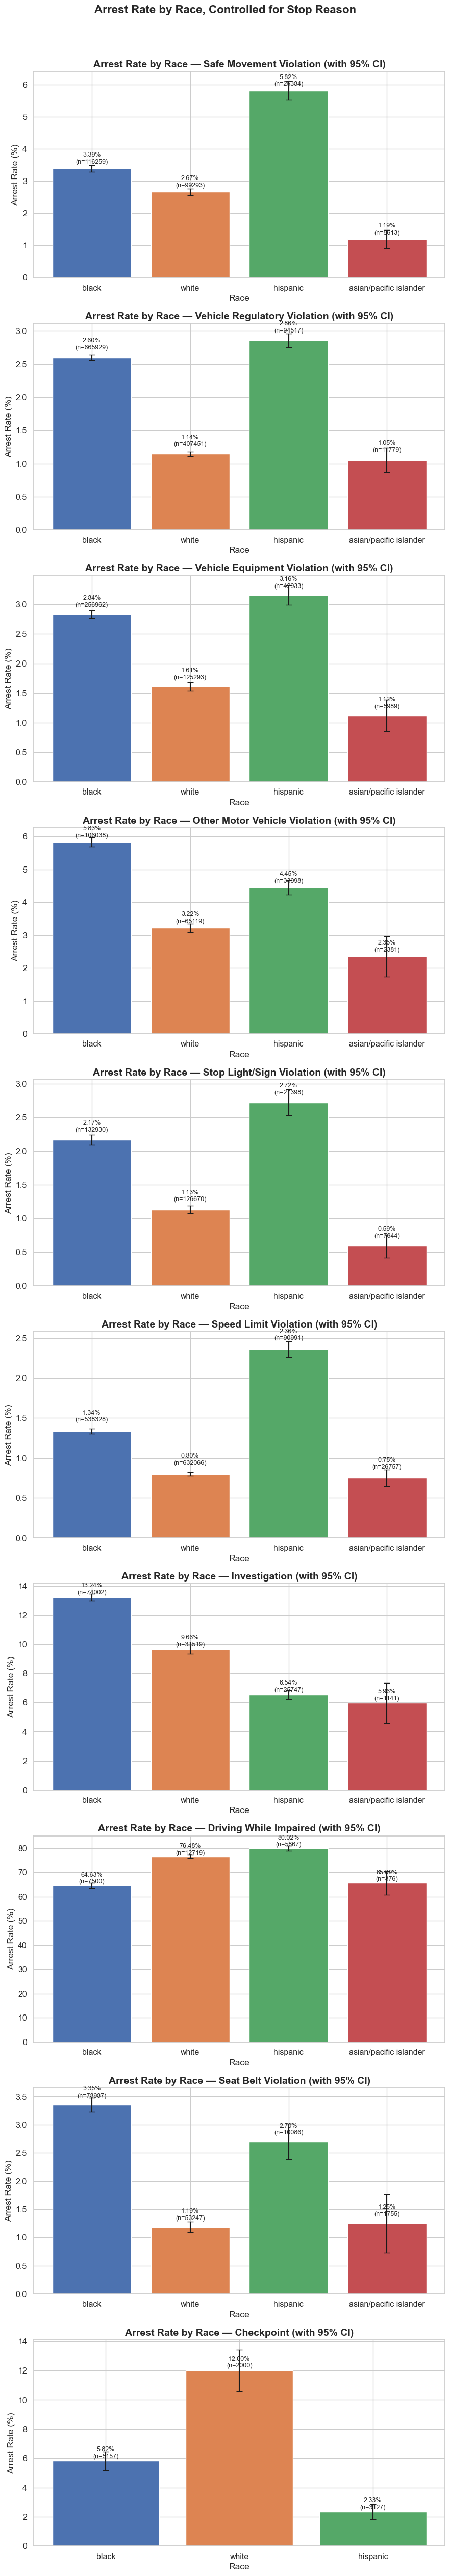

In [64]:
# Arrest Rate by Race controlling for Stop Reason (with 95% CI)
def arrest_rate_ci(group, z=1.96):
    n = len(group); p = group.mean()
    se = np.sqrt(p*(1-p)/n) if n > 0 else 0
    return pd.Series({"rate": p*100, "ci": z*se*100, "n": n})

# Get unique stop reasons
stop_reasons = df['reason_for_stop'].unique()

fig, axes = plt.subplots(
    nrows=len(stop_reasons), 
    figsize=(9, 5 * len(stop_reasons))
)

for ax, reason in zip(axes, stop_reasons):
    subset = df[df['reason_for_stop'] == reason]
    arr_race = subset.groupby("subject_race")["arrested"].apply(arrest_rate_ci).unstack()
    arr_race = arr_race.reindex([r for r in RACE_ORDER if r in arr_race.index])
    
    # Drop races with too few observations
    arr_race = arr_race[arr_race['n'] >= 200]

    bars = ax.bar(arr_race.index, arr_race["rate"], yerr=arr_race["ci"], capsize=4,
                  color=[PALETTE_RACE[r] for r in arr_race.index], edgecolor="white")
    
    ax.set_title(f"Arrest Rate by Race — {reason} (with 95% CI)", 
                 fontsize=14, fontweight="bold")
    ax.set_xlabel("Race")
    ax.set_ylabel("Arrest Rate (%)")
    
    for b, row in zip(bars, arr_race.itertuples()):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.1, 
                f"{row.rate:.2f}%\n(n={int(row.n)})",
                ha="center", va="bottom", fontsize=9)

plt.suptitle("Arrest Rate by Race, Controlled for Stop Reason", 
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

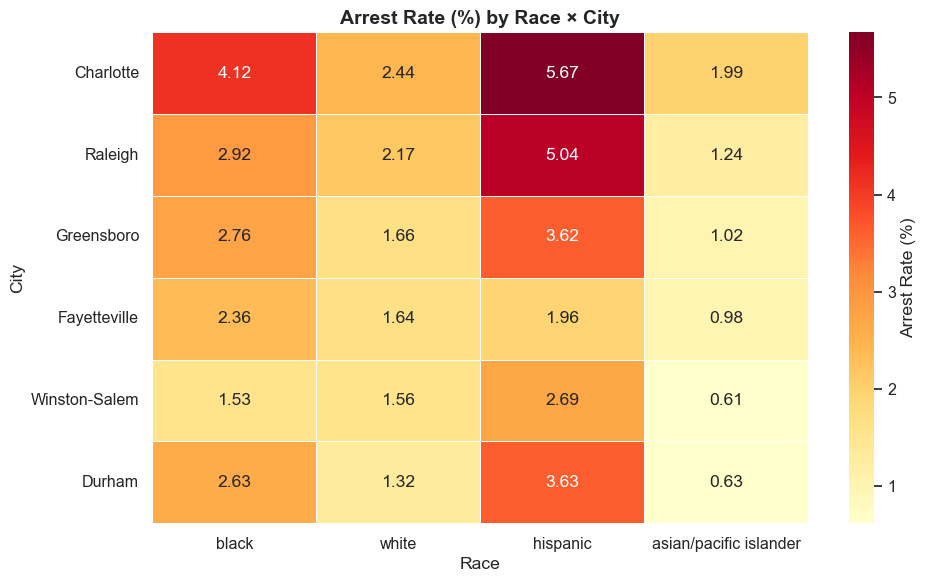

In [65]:
# Figure 2: Arrest Rate (%) by Race x City — Heatmap
arr_rc = df.groupby(["city", "subject_race"])["arrested"].mean().unstack() * 100
arr_rc = arr_rc.reindex(index=[c for c in CITY_ORDER if c in arr_rc.index],
                        columns=[r for r in RACE_ORDER if r in arr_rc.columns])

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(arr_rc, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5, ax=ax,
            cbar_kws={"label": "Arrest Rate (%)"})
ax.set_title("Arrest Rate (%) by Race × City", fontsize=14, fontweight="bold")
ax.set_xlabel("Race"); ax.set_ylabel("City")
plt.tight_layout()
plt.show()

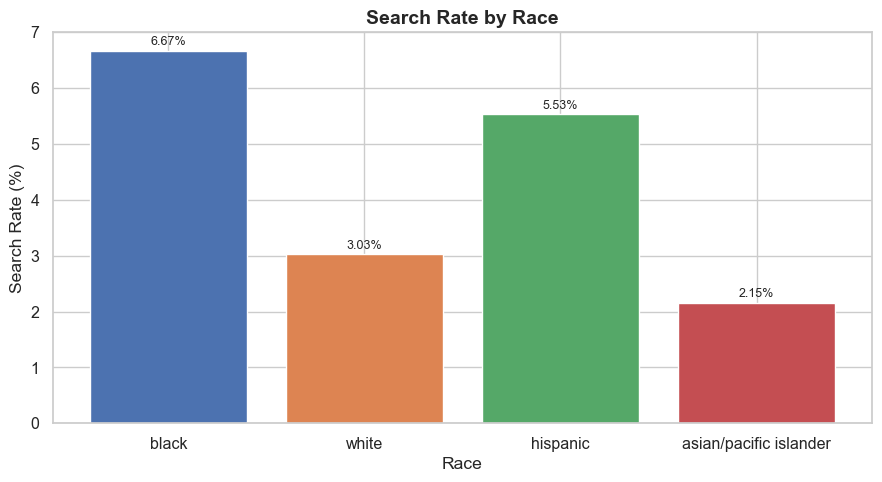

In [66]:
# Figure 3: Search Rate by Race
search_race = df.groupby("subject_race")["search_conducted"].mean() * 100
search_race = search_race.reindex([r for r in RACE_ORDER if r in search_race.index])

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(search_race.index, search_race.values,
              color=[PALETTE_RACE[r] for r in search_race.index], edgecolor="white")
ax.set_title("Search Rate by Race", fontsize=14, fontweight="bold")
ax.set_xlabel("Race"); ax.set_ylabel("Search Rate (%)")
for b, rate in zip(bars, search_race.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.05, f"{rate:.2f}%",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

## FBI Crime Data — Contextualizing Stop and Arrest Rates

In [67]:
# Load FBI Uniform Crime Report data for NC cities
fbi = pd.read_csv("nc_fbi_crime_data_clean.csv", index_col=0)
fbi["violent_crime_rate"] = fbi["Violent crime"] / fbi["Population"] * 1000
fbi["property_crime_rate"] = fbi["Property crime"] / fbi["Population"] * 1000
fbi = fbi.sort_values(["City", "Year"])
print(f"FBI data: {len(fbi)} city-year records, years {fbi['Year'].min()}–{fbi['Year'].max()}")
fbi[["City", "Year", "Population", "violent_crime_rate", "property_crime_rate"]].head(10)

FBI data: 52 city-year records, years 2006–2015


,City,Year,Population,violent_crime_rate,property_crime_rate
15,Charlotte,2006,699398,10.769262,69.897254
0,Charlotte,2007,733291,9.863751,69.929946
40,Charlotte,2008,758769,9.317724,61.855453
46,Charlotte,2009,777708,7.232792,49.546874
21,Charlotte,2010,797733,6.131124,43.499517
27,Charlotte,2011,789478,6.063500,40.543245
9,Charlotte,2012,808504,6.478632,40.305305
4,Charlotte,2013,837638,6.080192,36.494285
35,Charlotte,2014,856916,5.897894,35.668607
32,Charlotte,2015,877817,6.775900,37.678696


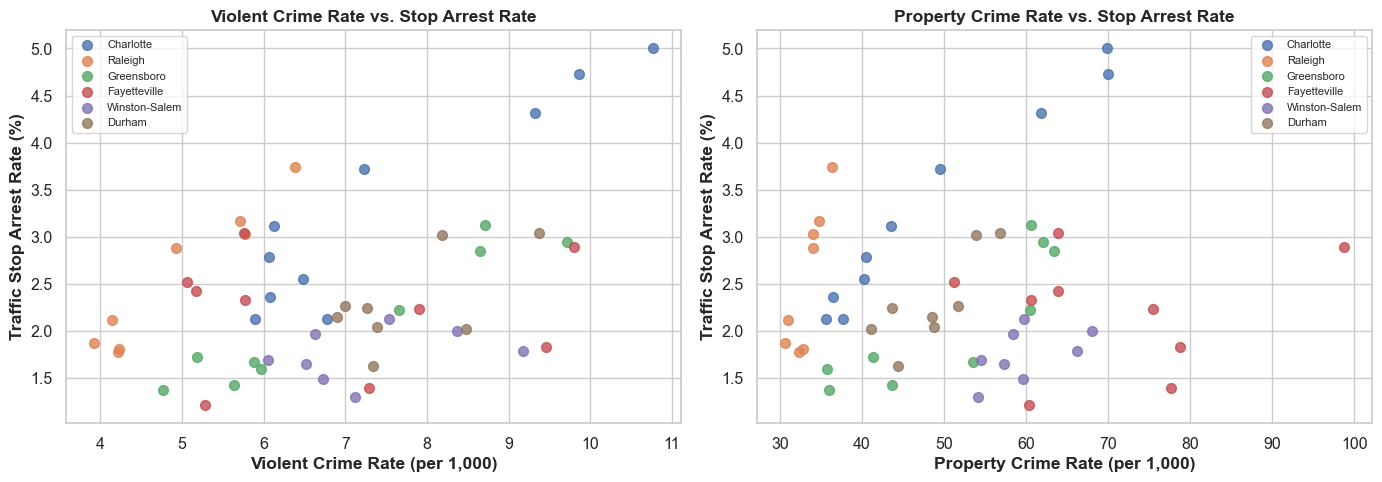

In [68]:
# Merge FBI crime rates with traffic stop arrest rates by city-year
stops_by_cy = df.groupby(["city", "year"]).agg(
    n_stops=("arrested", "size"),
    n_arrests=("arrested", "sum"),
    arrest_rate=("arrested", "mean")
).reset_index()
stops_by_cy["arrest_rate"] *= 100

merged = stops_by_cy.merge(fbi[["City", "Year", "violent_crime_rate", "property_crime_rate"]],
                           left_on=["city", "year"], right_on=["City", "Year"], how="inner")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, crime_col, label in zip(axes,
    ["violent_crime_rate", "property_crime_rate"],
    ["Violent Crime Rate (per 1,000)", "Property Crime Rate (per 1,000)"]):
    for city in CITY_ORDER:
        sub = merged[merged["city"] == city]
        ax.scatter(sub[crime_col], sub["arrest_rate"], label=city, s=50, alpha=0.8)
    ax.set_xlabel(label, fontweight="bold")
    ax.set_ylabel("Traffic Stop Arrest Rate (%)", fontweight="bold")
    ax.legend(fontsize=8)
axes[0].set_title("Violent Crime Rate vs. Stop Arrest Rate", fontweight="bold")
axes[1].set_title("Property Crime Rate vs. Stop Arrest Rate", fontweight="bold")
plt.tight_layout()
plt.show()

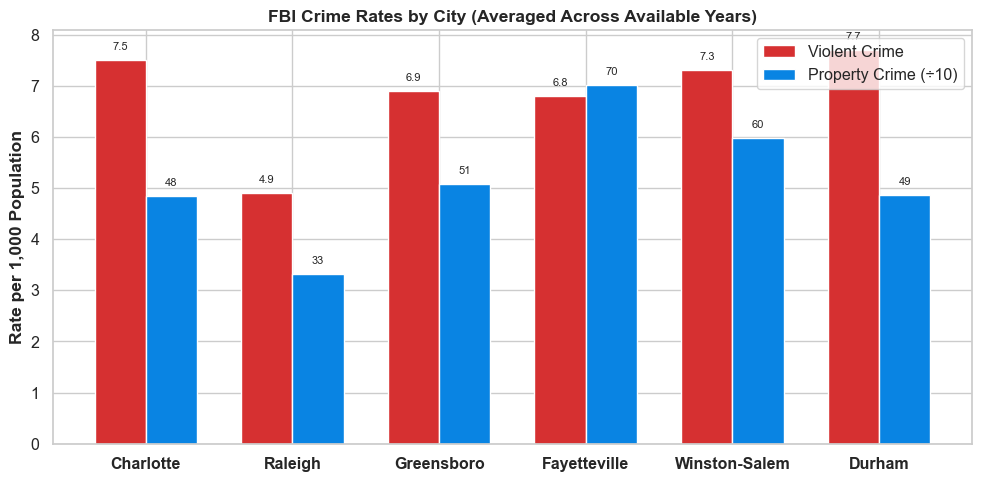

In [69]:
# FBI violent crime rate per capita by city (averaged across available years)
fbi_avg = fbi.groupby("City")[["violent_crime_rate", "property_crime_rate"]].mean().round(1)
fbi_avg = fbi_avg.reindex([c for c in CITY_ORDER if c in fbi_avg.index])

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(fbi_avg))
w = 0.35
ax.bar(x - w/2, fbi_avg["violent_crime_rate"], w, label="Violent Crime", color="#d63031")
ax.bar(x + w/2, fbi_avg["property_crime_rate"] / 10, w, label="Property Crime (÷10)", color="#0984e3")
ax.set_xticks(x)
ax.set_xticklabels(fbi_avg.index, fontweight="bold")
ax.set_ylabel("Rate per 1,000 Population", fontweight="bold")
ax.set_title("FBI Crime Rates by City (Averaged Across Available Years)", fontweight="bold")
ax.legend()
for i, (v, p) in enumerate(zip(fbi_avg["violent_crime_rate"], fbi_avg["property_crime_rate"])):
    ax.text(i - w/2, v + 0.2, f"{v:.1f}", ha="center", fontsize=8)
    ax.text(i + w/2, p/10 + 0.2, f"{p:.0f}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

## Inferential Analysis — Logistic Regression

P(Arrest | Driver Characteristics and Stop Conditions)

We use logistic regression to quantify the independent contribution of race, sex, and situational factors to the probability of arrest. All categorical variables are one-hot encoded with the first category dropped as a dummy variable. Library: `statsmodels`.

In [70]:
# Logistic Regression — full model with demographics + FBI crime rate
top_reasons = df["reason_for_stop"].value_counts().head(8).index.tolist()
dflog = df.copy()
# dflog["reason_cat"] = dflog["reason_for_stop"].where(dflog["reason_for_stop"].isin(top_reasons), "Other")
dflog["reason_cat"] = dflog["reason_for_stop"]
dflog = dflog[dflog['reason_cat'] != 'Driving While Impaired'].copy()

X = pd.get_dummies(
    dflog[["subject_race", "subject_sex", "subject_age",
           "reason_cat", "city", "search_conducted", "hour", "year",
           "violent_crime_rate"]],
    columns=["subject_race", "subject_sex", "reason_cat", "city"],
    drop_first=True, dtype=float)
X["search_conducted"] = X["search_conducted"].astype(float)
X.drop(columns=['search_conducted'], inplace=True)
X = sm.add_constant(X)
y = dflog["arrested"]
mask = X.notna().all(axis=1) & y.notna()
X, y = X[mask], y[mask]

model = sm.Logit(y, X).fit(disp=0, maxiter=200)
print(f"Pseudo R²: {model.prsquared:.4f}")
print(f"Observations: {int(model.nobs):,}")

res = pd.DataFrame({
    "coef": model.params, "std_err": model.bse, "z": model.tvalues,
    "p_value": model.pvalues, "odds_ratio": np.exp(model.params),
    "or_ci_lower": np.exp(model.conf_int()[0]),
    "or_ci_upper": np.exp(model.conf_int()[1])
})
res[res["p_value"] < 0.05][["odds_ratio", "or_ci_lower", "or_ci_upper", "p_value"]].round(4)

Pseudo R²: 0.0980
Observations: 3,934,560


,odds_ratio,or_ci_lower,or_ci_upper,p_value
const,7.199728e+41,1.363346e+40,3.802121e+43,0.0
subject_age,9.778000e-01,9.772000e-01,9.784000e-01,0.0
hour,9.774000e-01,9.765000e-01,9.783000e-01,0.0
year,9.517000e-01,9.498000e-01,9.535000e-01,0.0
violent_crime_rate,1.067200e+00,1.061300e+00,1.073100e+00,0.0
subject_race_black,2.666300e+00,2.466500e+00,2.882200e+00,0.0
subject_race_hispanic,2.165100e+00,1.999300e+00,2.344700e+00,0.0
subject_race_white,1.468200e+00,1.357300e+00,1.588100e+00,0.0
subject_sex_male,2.596000e+00,2.551700e+00,2.641100e+00,0.0
reason_cat_Investigation,1.409400e+00,1.294800e+00,1.534100e+00,0.0


In [71]:
X = pd.get_dummies(
    dflog[["subject_race", "subject_sex", "subject_age",
           "reason_cat", "city", "search_conducted", "hour", "year",
           "violent_crime_rate"]],
    columns=["subject_race", "subject_sex", "reason_cat", "city"],
    drop_first=True, dtype=float)
X["search_conducted"] = X["search_conducted"].astype(float)


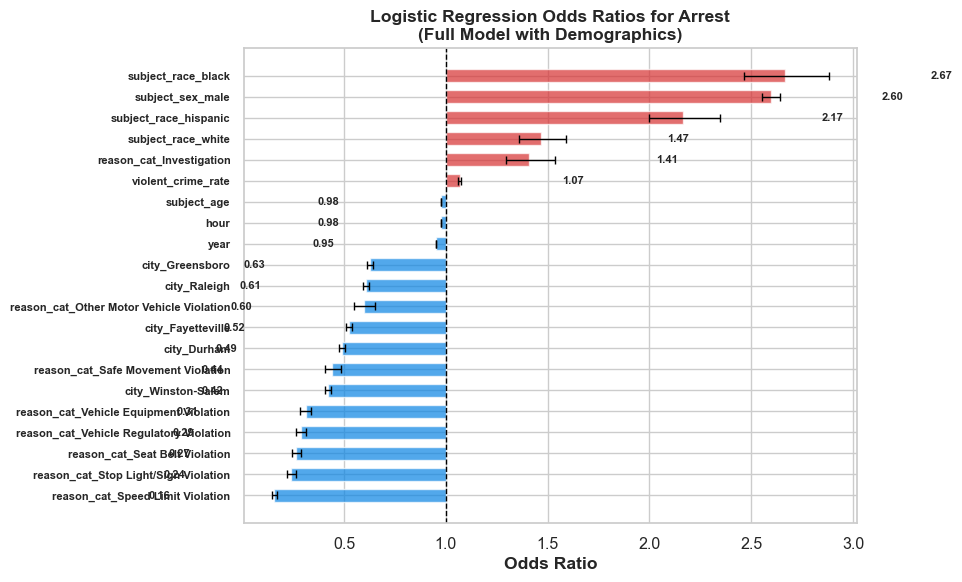

In [72]:
# Figure 4: Odds Ratios — significant features only
plot_df = res.drop(index=["const"], errors="ignore").copy()
# plot_df = plot_df[plot_df["p_value"] < 0.05].sort_values("odds_ratio")
plot_df = plot_df.sort_values("odds_ratio")

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#d63031" if v > 1 else "#0984e3" for v in plot_df["odds_ratio"]]
ax.barh(range(len(plot_df)), plot_df["odds_ratio"] - 1, left=1,
        color=colors, alpha=0.7, height=0.6)
ax.errorbar(plot_df["odds_ratio"], range(len(plot_df)),
            xerr=[plot_df["odds_ratio"] - plot_df["or_ci_lower"],
                  plot_df["or_ci_upper"] - plot_df["odds_ratio"]],
            fmt="none", ecolor="black", capsize=3, linewidth=1)
for i, (idx, row) in enumerate(plot_df.iterrows()):
    orv = row["odds_ratio"]
    offset = row["or_ci_upper"] + 0.5 if orv >= 1 else row["or_ci_lower"] - 0.5
    ha = "left" if orv >= 1 else "right"
    ax.text(offset, i, f"{orv:.2f}", va="center", ha=ha, fontsize=8, fontweight="bold")
ax.axvline(1, color="black", ls="--", lw=1)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df.index, fontsize=8, fontweight="bold")
ax.set_xlabel("Odds Ratio", fontweight="bold")
ax.set_title("Logistic Regression Odds Ratios for Arrest\n(Full Model with Demographics)", fontweight="bold")
plt.tight_layout()
plt.show()

## Race-Blind Predictive Model

Gradient-boosted classifier trained **without Race or Sex** to predict arrest based solely on situational context (stop reason, location, search status, time, age). We use `class_weight="balanced"` to address the 97:3 class imbalance, and select the optimal classification threshold by maximizing the F1 score on the test set.

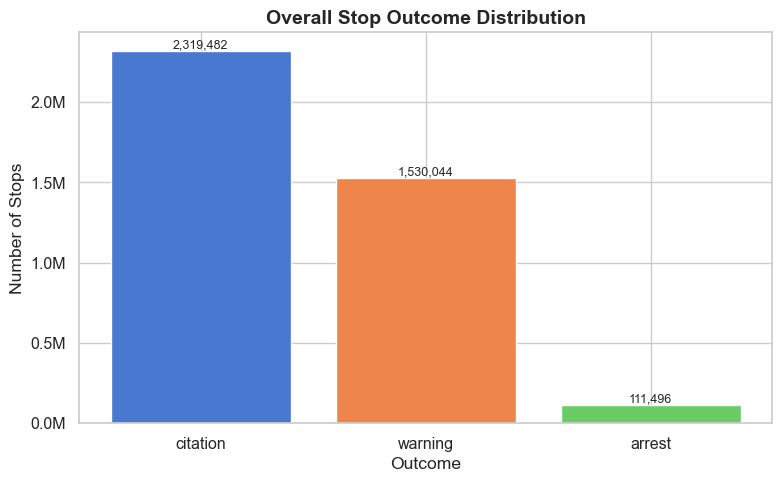

In [73]:
# Figure 5: Class imbalance — Overall Stop Outcome Distribution
outcome_counts = df[df["outcome"] != "nan"]["outcome"].value_counts()
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(outcome_counts.index, outcome_counts.values,
              color=sns.color_palette("muted", len(outcome_counts)))
ax.set_title("Overall Stop Outcome Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Outcome"); ax.set_ylabel("Number of Stops")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height(), f"{b.get_height():,.0f}",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

In [74]:
# Build race-blind model — 80/20 train-test split (includes FBI crime rate)
dfm = df.copy()
# dfm["reason_cat"] = dfm["reason_for_stop"].where(
#     dfm["reason_for_stop"].isin(top_reasons), "Other")
dfm["reason_cat"] = dfm["reason_for_stop"]
dfm = dfm[dfm['reason_cat'] != 'Driving While Impaired'].copy()

le_r = LabelEncoder(); le_c = LabelEncoder(); le_d = LabelEncoder()
dfm["reason_enc"] = le_r.fit_transform(dfm["reason_cat"])
dfm["city_enc"] = le_c.fit_transform(dfm["city"])
dfm["dow_enc"] = le_d.fit_transform(dfm["day_of_week"])

feat_cols = ["subject_age", "reason_enc", "city_enc", "hour", "year", "month", "dow_enc", "violent_crime_rate"]
feat_names = ["Age", "Stop Reason", "City", "Hour", "Year", "Month", "Day of Week", "Violent Crime Rate (FBI)"]

Xm = dfm[feat_cols].copy()
ym = dfm["arrested"]

X_tr, X_te, y_tr, y_te = train_test_split(Xm, ym, test_size=0.2,
                                           random_state=SEED, stratify=ym)

clf = HistGradientBoostingClassifier(max_iter=300, max_depth=6, learning_rate=0.1,
                                     min_samples_leaf=100, random_state=SEED,
                                     class_weight="balanced")
clf.fit(X_tr, y_tr)
prob_te = clf.predict_proba(X_te)[:, 1]
print("Model trained (with FBI violent crime rate feature).")

Model trained (with FBI violent crime rate feature).


## Performance Metrics

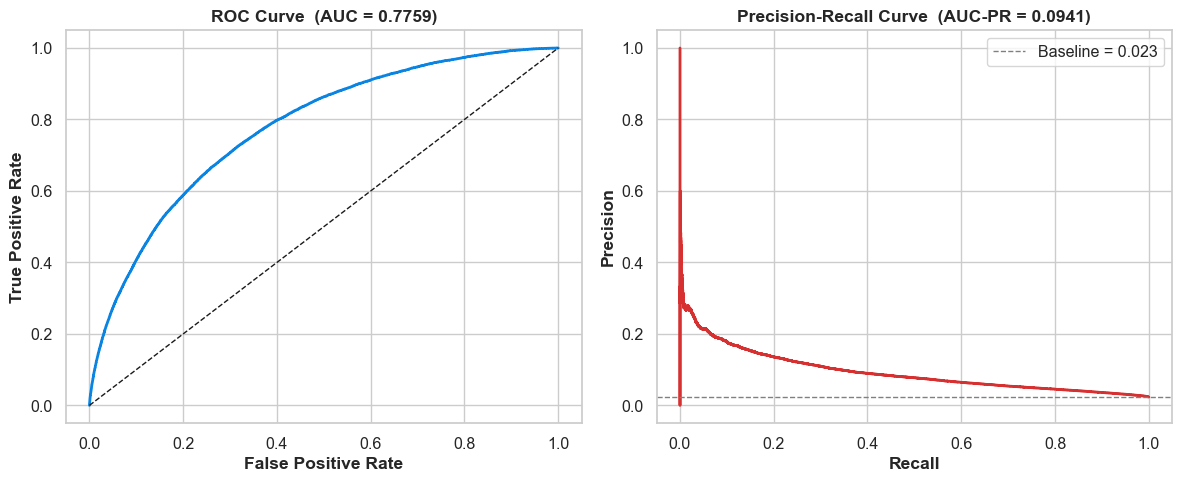

In [75]:
# Figure 6: ROC Curve + Precision-Recall Curve
auc_roc = roc_auc_score(y_te, prob_te)
auc_pr = average_precision_score(y_te, prob_te)
fpr, tpr, _ = roc_curve(y_te, prob_te)
prec, rec, _ = precision_recall_curve(y_te, prob_te)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(fpr, tpr, color="#0984e3", lw=2)
ax1.plot([0, 1], [0, 1], "k--", lw=1)
ax1.set_xlabel("False Positive Rate", fontweight="bold")
ax1.set_ylabel("True Positive Rate", fontweight="bold")
ax1.set_title(f"ROC Curve  (AUC = {auc_roc:.4f})", fontweight="bold")

ax2.plot(rec, prec, color="#d63031", lw=2)
baseline = y_te.mean()
ax2.axhline(baseline, color="gray", ls="--", lw=1, label=f"Baseline = {baseline:.3f}")
ax2.set_xlabel("Recall", fontweight="bold")
ax2.set_ylabel("Precision", fontweight="bold")
ax2.set_title(f"Precision-Recall Curve  (AUC-PR = {auc_pr:.4f})", fontweight="bold")
ax2.legend()
plt.tight_layout()
plt.show()

In [76]:
# Performance summary + Confusion Matrix at optimal F1 threshold
thresholds = np.arange(0.001, 0.999, 0.001)
f1s = [f1_score(y_te, (prob_te >= t).astype(int)) for t in thresholds]
best_t = thresholds[np.argmax(f1s)]
best_f1 = max(f1s)
y_pred = (prob_te >= best_t).astype(int)
cm = confusion_matrix(y_te, y_pred)
precision = precision_score(y_te, y_pred)
recall = recall_score(y_te, y_pred)

print(f"Baseline (arrest rate):  {baseline:.4f}")
print(f"AUC-ROC:                 {auc_roc:.4f}")
print(f"AUC-PR:                  {auc_pr:.4f}")
print(f"Best F1 Score:           {best_f1:.4f}")
print(f"Precision:               {precision:.4f}")
print(f"Recall:                  {recall:.4f}")
print(f"Optimal Threshold:       {best_t:.3f}")
print(f"\nConfusion Matrix (threshold = {best_t:.3f}):")
cm_df = pd.DataFrame(cm, index=["Actual No Arrest", "Actual Arrest"],
                         columns=["Predicted No Arrest", "Predicted Arrest"])
cm_df

Baseline (arrest rate):  0.0234
AUC-ROC:                 0.7759
AUC-PR:                  0.0941
Best F1 Score:           0.1640
Precision:               0.1298
Recall:                  0.2225
Optimal Threshold:       0.789

Confusion Matrix (threshold = 0.789):


,Predicted No Arrest,Predicted Arrest
Actual No Arrest,741067,27449
Actual Arrest,14302,4094


## Feature Importance

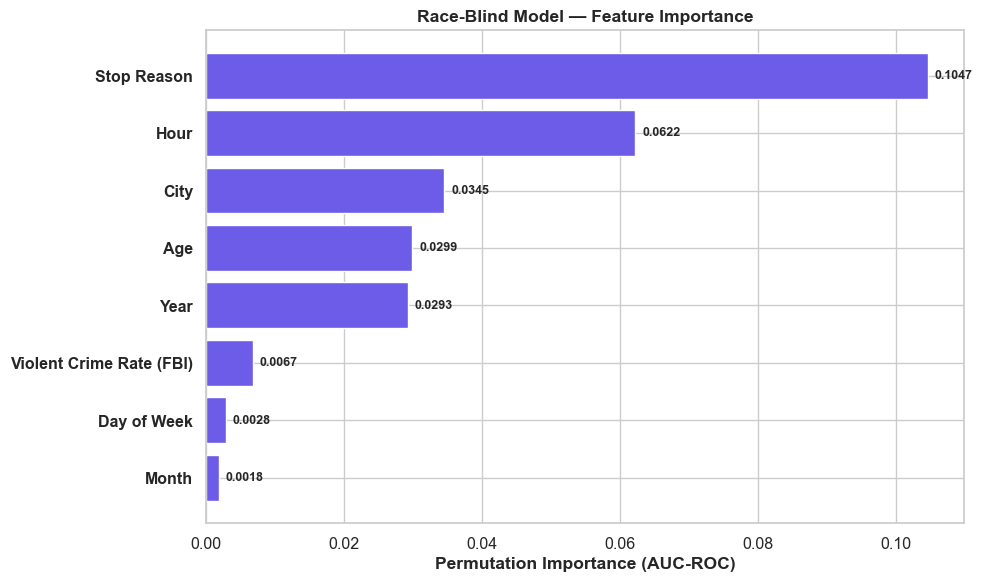

In [77]:
# Figure 7: Permutation Importance (race-blind model)
sample_idx = np.random.RandomState(SEED).choice(len(X_te), min(20_000, len(X_te)), replace=False)
pi = permutation_importance(clf, X_te.iloc[sample_idx], y_te.iloc[sample_idx],
                            n_repeats=5, random_state=SEED, scoring="roc_auc")
imp = pi.importances_mean
order = np.argsort(imp)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(len(imp)), imp[order], color="#6c5ce7")
for bar, idx in zip(bars, order):
    val = imp[idx]
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9, fontweight="bold")
ax.set_yticks(range(len(imp)))
ax.set_yticklabels([feat_names[i] for i in order], fontweight="bold")
ax.set_xlabel("Permutation Importance (AUC-ROC)", fontweight="bold")
ax.set_title("Race-Blind Model — Feature Importance", fontweight="bold")
plt.tight_layout()
plt.show()

## Initial Flagging System

In [78]:
# Sets a historical suspicion threshold for each city acccording to a 15% deviation from the historical average suspicion
Xm['city'] = df.loc[Xm.index, 'city']
Xm['arrested'] = df.loc[Xm.index, 'arrested']
Xm['predicted_prob'] = clf.predict_proba(Xm[feat_cols])[:, 1]
arrested = Xm[Xm['arrested'] == 1].sort_values(['city', 'year'])

# Expand across all rows, keeping year as a column not a groupby key
hist = (arrested.groupby('city', group_keys=False).apply(lambda g: g.assign(
        historical_average_suspicion=g['predicted_prob'].expanding().mean(),
        historical_suspicion_std=g['predicted_prob'].expanding().std())))

# Take last row per city/year to get cumulative stats through each year, creating a rolling average and standard deviation of suspicion
historical_suspicion_data = (hist.groupby(['city', 'year']).last().reset_index()[['city', 'year', 'historical_average_suspicion', 'historical_suspicion_std']])

# Shifts the historical average and standard deviation to the previous year
historical_suspicion_data['historical_average_suspicion'] = (historical_suspicion_data.groupby('city')['historical_average_suspicion'].shift(1))
historical_suspicion_data['historical_suspicion_std'] = (historical_suspicion_data.groupby('city')['historical_suspicion_std'].shift(1))

historical_suspicion_data['historical_suspicion_threshold'] = historical_suspicion_data['historical_average_suspicion'] - (historical_suspicion_data['historical_suspicion_std']*.5)

# Gathers the resulted predicted probabilities for each city
X_te['predicted_prob'] = prob_te
results = X_te.copy()
results['arrested'] = y_te
results['subject_race'] = df.loc[X_te.index, 'subject_race']
results['subject_sex'] = df.loc[X_te.index, 'subject_sex']
results['city'] = df.loc[X_te.index, 'city']
# results['subject_sex'] = df.loc[X_te.index, 'subject_sex']
results['season'] = results['month'].apply(lambda x: 'Spring' if x in [3, 4, 5] else 'Summer' if x in [6, 7, 8] else 'Fall' if x in [9, 10, 11] else 'Winter')
historical_suspicion_data.dropna(inplace=True)
historical_suspicion_data.reset_index(inplace=True)

# Tests the performance of the flagging system with different groupings
for grouping in [['city', 'year', 'subject_race'], ['city', 'year', 'subject_sex', 'subject_race'], ['city', 'year', 'subject_race', 'subject_sex', 'season'], ['city', 'year', 'subject_sex', 'season'], ['city', 'year', 'subject_sex'], ['city', 'year', 'subject_race', 'season']]:
    # Gathers the average suspicion for each city, year, and season
    city_audit = results[results['arrested'] == 1].groupby(grouping).agg(total_arrests=('arrested', 'sum'), average_suspicion=('predicted_prob', 'mean'))

    # Combines the historical suspicion threshold with the average suspicion for each city and filters for cities that have had at least 30 arrests
    city_audit.reset_index(inplace=True)
    city_audit = city_audit.merge(historical_suspicion_data, on=['city', 'year'])
    city_audit['total_arrests'] = city_audit['total_arrests'].astype(int)
    city_audit['flag'] = np.where(((city_audit['average_suspicion'] < city_audit['historical_suspicion_threshold']) & (city_audit['total_arrests'] >= 30)), 1, 0)
    print(f'The Grouping is: {grouping}')
    print(f"Total groups:  {len(city_audit)}")
    print(f"Flagged groups: {city_audit['flag'].sum()}")
    print(f"Flag rate: {city_audit['flag'].mean():.2%}")

    print(city_audit[city_audit['flag'] == 1])
    try:
        print(city_audit[city_audit['flag'] == 1]['subject_race'].value_counts())
    except:
        print(city_audit[city_audit['flag'] == 1]['subject_sex'].value_counts())

The Grouping is: ['city', 'year', 'subject_race']
Total groups:  285
Flagged groups: 27
Flag rate: 9.47%
             city  year subject_race  total_arrests  average_suspicion  index  \
31      Charlotte  2009        black            603           0.632955      9   
35      Charlotte  2010        black            418           0.608437     10   
37      Charlotte  2010        white            145           0.601282     10   
39      Charlotte  2011        black            402           0.577670     11   
43      Charlotte  2012        black            337           0.586255     12   
47      Charlotte  2013        black            353           0.554479     13   
51      Charlotte  2014        black            344           0.546630     14   
55      Charlotte  2015        black            262           0.556319     15   
79         Durham  2010        black             73           0.518028     24   
93         Durham  2014        black             44           0.464563     28   
136 

## Flagging System by Sex

In [79]:
city_audit = results[results['arrested'] == 1].groupby(['city', 'year', 'subject_sex']).agg(total_arrests=('arrested', 'sum'), average_suspicion=('predicted_prob', 'mean'))

# Combines the historical suspicion threshold with the average suspicion for each city and filters for cities that have had at least 30 arrests
city_audit.reset_index(inplace=True)
city_audit = city_audit.merge(historical_suspicion_data, on=['city', 'year'])
city_audit['total_arrests'] = city_audit['total_arrests'].astype(int)
city_audit['flag'] = np.where(((city_audit['average_suspicion'] < city_audit['historical_suspicion_threshold']) & (city_audit['total_arrests'] >= 30)), 1, 0)
print(f'The Grouping is: {grouping}')
print(f"Total groups:  {len(city_audit)}")
print(f"Flagged groups: {city_audit['flag'].sum()}")
print(f"Flag rate: {city_audit['flag'].mean():.2%}")

print(city_audit[city_audit['flag'] == 1])
print(city_audit[city_audit['flag'] == 1]['subject_sex'].value_counts())

The Grouping is: ['city', 'year', 'subject_race', 'season']
Total groups:  166
Flagged groups: 27
Flag rate: 16.27%
             city  year subject_sex  total_arrests  average_suspicion  index  \
19      Charlotte  2010        male            545           0.612671     10   
20      Charlotte  2011      female            133           0.584609     11   
21      Charlotte  2011        male            480           0.601068     11   
22      Charlotte  2012      female             92           0.603065     12   
23      Charlotte  2012        male            390           0.594027     12   
24      Charlotte  2013      female            100           0.564497     13   
25      Charlotte  2013        male            445           0.581929     13   
26      Charlotte  2014      female            123           0.580145     14   
27      Charlotte  2014        male            428           0.572131     14   
28      Charlotte  2015      female             96           0.576822     15   
29  

## Flagging System by Race

In [80]:
city_audit = results[results['arrested'] == 1].groupby(['city', 'year', 'subject_race']).agg(total_arrests=('arrested', 'sum'), average_suspicion=('predicted_prob', 'mean'))

# Combines the historical suspicion threshold with the average suspicion for each city and filters for cities that have had at least 30 arrests
city_audit.reset_index(inplace=True)
city_audit = city_audit.merge(historical_suspicion_data, on=['city', 'year'])
city_audit['total_arrests'] = city_audit['total_arrests'].astype(int)
city_audit['flag'] = np.where(((city_audit['average_suspicion'] < city_audit['historical_suspicion_threshold']) & (city_audit['total_arrests'] >= 30)), 1, 0)
print(f'The Grouping is: {grouping}')
print(f"Total groups:  {len(city_audit)}")
print(f"Flagged groups: {city_audit['flag'].sum()}")
print(f"Flag rate: {city_audit['flag'].mean():.2%}")

print(city_audit[city_audit['flag'] == 1])
print(city_audit[city_audit['flag'] == 1]['subject_race'].value_counts())

The Grouping is: ['city', 'year', 'subject_race', 'season']
Total groups:  285
Flagged groups: 27
Flag rate: 9.47%
             city  year subject_race  total_arrests  average_suspicion  index  \
31      Charlotte  2009        black            603           0.632955      9   
35      Charlotte  2010        black            418           0.608437     10   
37      Charlotte  2010        white            145           0.601282     10   
39      Charlotte  2011        black            402           0.577670     11   
43      Charlotte  2012        black            337           0.586255     12   
47      Charlotte  2013        black            353           0.554479     13   
51      Charlotte  2014        black            344           0.546630     14   
55      Charlotte  2015        black            262           0.556319     15   
79         Durham  2010        black             73           0.518028     24   
93         Durham  2014        black             44           0.464563     